# FaSt-SWOT drifters processing showcase notebook

Author(s) : Daniel R., Tarry, Laura Gómez Navarro, Elisabet Verger-Miralles

Objective: Describe the steps done to process the drifter L0 (raw) data. This notebook showcases and example with a CARTHE drifter.  See specific notebooks for 'in-practice' processing.

Created on: October 2023

Last updated on:

In [1]:
import time
print(time.ctime(time.time()))

Fri Dec 15 13:25:37 2023


<a id="0"></a> <br>
# Table of Contents  
1. [Load data](#1)     
2. [Processing](#2)
    1. [Identification of large data gaps](#2.1.)
    2. [Resampling to regular 10 min intervals](#2.2.)
        1. [Making lon and lat variables instead of coordinates](#2.2.1.)
        2. [Resampling](#2.2.2.)
    3. [Velocity calculation](#2.3.)
    4. [Spike cleaning](#2.4.)
        1. [2.4.1. Large spikes removal](#2.4.1.)
        2. [2.4.2. Smaller spike removal](#2.4.2.)
    5. [Smoothing](#2.5.)
        1. [Interpolation](#2.5.1.)
        2. [Window smoothing](#2.5.2.)
    6. [Recalculate velocity](#2.6.)

In [2]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt 
import scipy.signal as signal

from read_data_tools_xr import haversine, latlon2uv_dir

### Parameters

In [3]:
url_drifter = "drifter_carthe006-ime_carthe001/L0/2023/dep0002_drifter-carthe006_ime-carthe001_L0_2023-04-26.nc?"
drifter_type = 'C' # C: CARTHE ; H: Hereon ; S: SVP-B 
diff_time_thres = 3600 * 2 # [s] 2h # Will be different for SVP, higher as time res. is 1hr

# n_window = 12 # we leave like this for now

<a id="1"></a> 
# 1. Load Data

In [4]:
# Main root
url_root = "http://thredds.socib.es/thredds/dodsC/drifter/surface_drifter/"

In [5]:
# parameters of the thredd file

if drifter_type == 'C':
    url_vars = "trajectory,time[0:1:-1],DEPTH,LAT[0:1:-1],LON[0:1:-1],BAT_STATUS[0:1:-1]"
    temp_res = 600. # Specifying seconds 
    # Step depending on drifter (CARTHE and HEREON 600s (10 mins (we choose the highest time resolution)) 
elif drifter_type == 'H':
    url_vars = "trajectory,time[0:1:-1],LAT[0:1:-1],LON[0:1:-1],DEPTH,PLAT_SPEED_GR[0:1:-1],PLAT_COURSE[0:1:-1],BAT_STATUS[0:1:-1]"
    temp_res = 600. # Specifying seconds 
    # Step depending on drifter (CARTHE and HEREON 600s (10 mins (we choose the highest time resolution)) 
elif drifter_type == 'S':
    url_vars = "trajectory"
    temp_res = 3600. # Specifying seconds 
else:
    print('Hereon is the same, add option, SVP missing temp , press , BAT_status different')
    fsdfs

In [6]:
url = url_root + url_drifter + url_vars
print(url)

http://thredds.socib.es/thredds/dodsC/drifter/surface_drifter/drifter_carthe006-ime_carthe001/L0/2023/dep0002_drifter-carthe006_ime-carthe001_L0_2023-04-26.nc?trajectory,time[0:1:-1],DEPTH,LAT[0:1:-1],LON[0:1:-1],BAT_STATUS[0:1:-1]


In [7]:
# To work offline
# fname = 'dep0002_drifter-carthe006_ime-carthe001_L1_2023-04-26.nc'

In [8]:
# Load file
ds00 = xr.open_dataset(url)
# ds00  = xr.open_dataset(fname)
ds00

<xarray.Dataset>
Dimensions:     (time: 4255)
Coordinates:
  * time        (time) datetime64[ns] 2023-04-26T10:16:51 ... 2023-05-28T19:1...
    DEPTH       float64 ...
    LAT         (time) float64 ...
    LON         (time) float64 ...
Data variables:
    trajectory  |S64 ...
    BAT_STATUS  (time) float64 ...
Attributes: (12/67)
    title:                               Data from instrument IME-CARTHE001 o...
    institution:                         IMEDEA (Instituto MEDiterráneo de Es...
    netcdf_version:                      3.0
    Conventions:                         CF-1.6
    abstract:                            Deployment of IME-CARTHE001 in FaSt-...
    summary:                             Deployment of IME-CARTHE001 in FaSt-...
    ...                                  ...
    citation:                            Balearic Island Coastal and Observin...
    acknowledgement:                     The FaSt-SWOT project is funded by t...
    update_interval:                     every 3600 seconds
    DODS.strlen:                         34
    DODS.dimName:                        name_strlen
    DODS_EXTRA.Unlimited_Dimension:      time

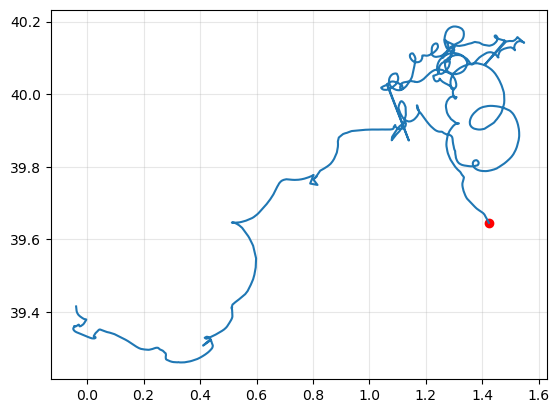

In [9]:
plt.plot(ds00.LON, ds00.LAT)
plt.scatter(ds00.LON[0], ds00.LAT[0], c='r')
plt.grid(alpha=0.3)

<a id="2"></a> 
# 2. Procesing

In [10]:
# Checking time interval:

print(ds00.time[0].data)
print(ds00.time[1].data)

# --> Should be: 
# 10 mins freq. for CARTHE
# 5 mins HEREON
# 1h SVP-B

2023-04-26T10:16:51.000000000
2023-04-26T10:26:48.000000000


<a id="2.1."></a> 
## 2.1. Identification of large data gaps

In [12]:
dt_drif = ds00.time.diff("time").dt.seconds

In [13]:
# just using np.where, find cleaner method with array to find indices:
inds_trash = np.where(dt_drif > diff_time_thres)[0]
inds_trash

array([3316, 3333, 3334, 3343])

In [14]:
if inds_trash.size > 0: 
    ds01 = ds00.where(ds00.time<ds00.time[inds_trash[0]+2], drop=True) # to improve 
    # + 2 because +1 of normal python indices , and 1 more because based on the indices of the array of time differences
elif inds_trash.size == 0:
    ds01 = ds00.copy()
else:
    print('Problem')
    fsdgsdfg

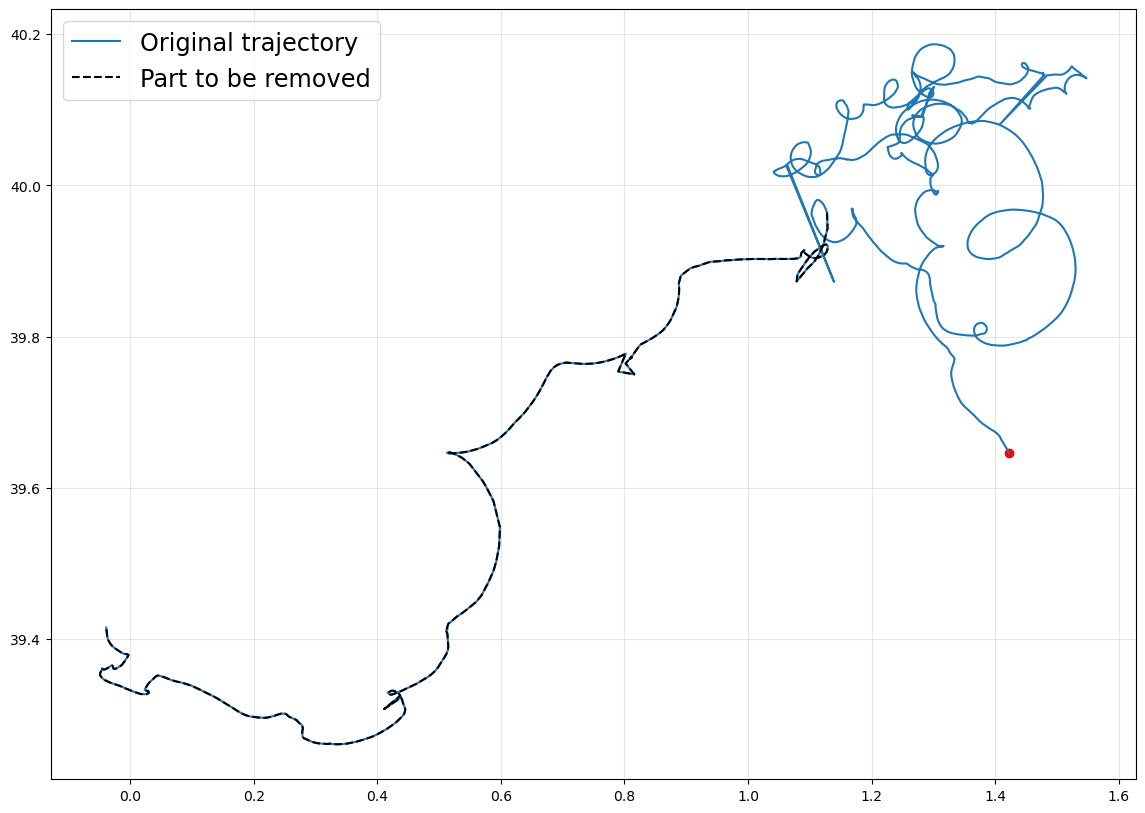

In [15]:
if inds_trash.size > 0: 
    plt.figure(figsize=(14,10))
    plt.plot(ds00.LON, ds00.LAT, label='Original trajectory')
    plt.scatter(ds00.LON[0], ds00.LAT[0], c='r')
    plt.plot(ds00.LON[inds_trash[0]::], ds00.LAT[inds_trash[0]::], '--k', label='Part to be removed')
    plt.legend(fontsize='xx-large')
    plt.grid(alpha=0.3)
else:
    print(f'Nothing to plot, no gap bigger than {diff_time_thres/3600} hours')

<a id="2.2."></a> 
## 2.2. Resampling to regular 10 min intervals

<a id="2.2.1."></a> 
### 2.2.1. Making lon and lat variables instead of coordinates

If we do not do this step when resampling we loose lon and lat in the dataset. To keep in mind that this may give problems in further calculations with xarray that might need lon and lat as coords.

In [16]:
ds01 = ds01.reset_coords("LON")
ds01 = ds01.reset_coords("LAT")
ds01

<xarray.Dataset>
Dimensions:     (time: 3318)
Coordinates:
  * time        (time) datetime64[ns] 2023-04-26T10:16:51 ... 2023-05-20T03:0...
    DEPTH       float64 0.6
Data variables:
    trajectory  (time) object b'drifter-carthe006_ime-carthe001_L0' ... b'dri...
    BAT_STATUS  (time) float64 1.0 1.0 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0 1.0
    LAT         (time) float64 39.65 39.65 39.65 39.65 ... 39.97 39.96 39.94
    LON         (time) float64 1.423 1.422 1.422 1.421 ... 1.127 1.128 1.129
Attributes: (12/67)
    title:                               Data from instrument IME-CARTHE001 o...
    institution:                         IMEDEA (Instituto MEDiterráneo de Es...
    netcdf_version:                      3.0
    Conventions:                         CF-1.6
    abstract:                            Deployment of IME-CARTHE001 in FaSt-...
    summary:                             Deployment of IME-CARTHE001 in FaSt-...
    ...                                  ...
    citation:                            Balearic Island Coastal and Observin...
    acknowledgement:                     The FaSt-SWOT project is funded by t...
    update_interval:                     every 3600 seconds
    DODS.strlen:                         34
    DODS.dimName:                        name_strlen
    DODS_EXTRA.Unlimited_Dimension:      time

<a id="2.2.2."></a> 
### 2.2.2. Resampling

In [17]:
ds02 = ds01.resample(time=f"{int(temp_res)}s").interpolate("linear") # xarray resample works very differently from pandas


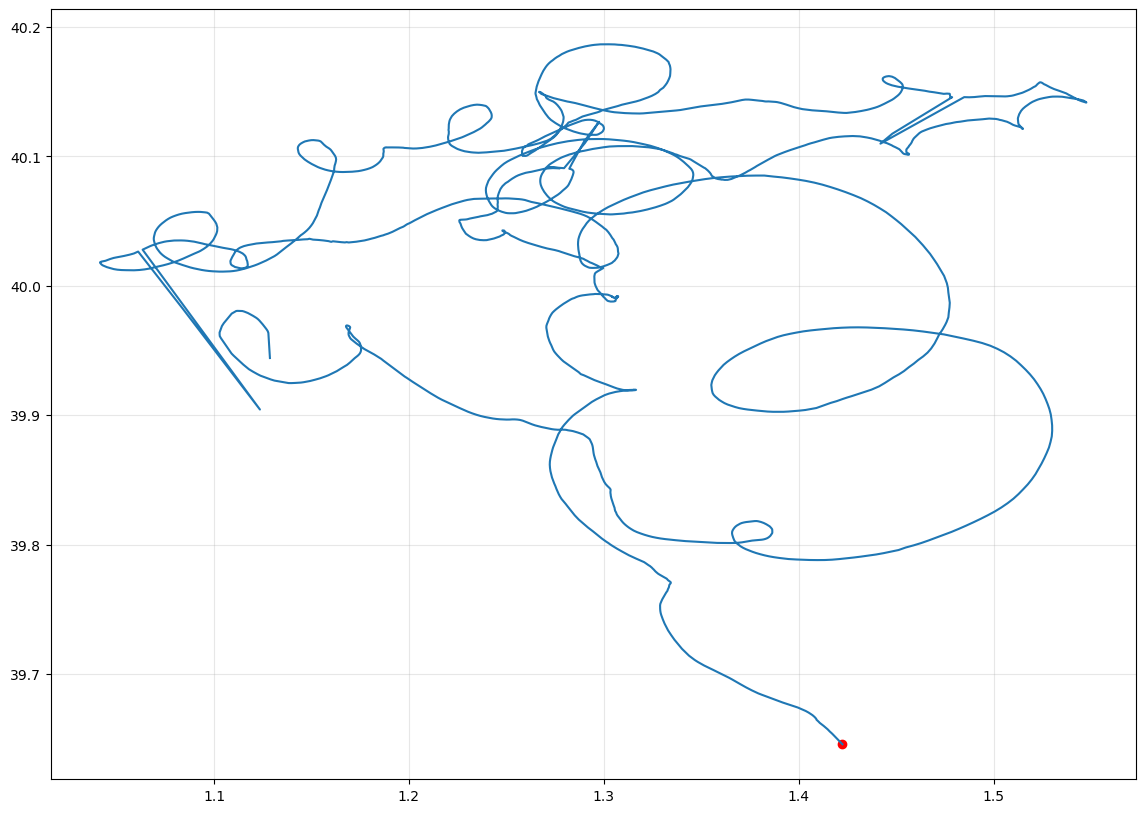

In [18]:
plt.figure(figsize=(14,10))
plt.plot(ds02.LON, ds02.LAT)
# plt.scatter(ds02.LON[0], ds02.LAT[0], c='r') # first point is nan now
plt.scatter(ds02.LON[1], ds02.LAT[1], c='r')
plt.grid(alpha=0.3)

<a id="2.3."></a> 
## 2.3. Velocity calculation

Backwards vel. calculated at t-1 and forward at t+1. To keep initial dimensions, extra value assigned nan.

In [19]:
# Calculate forward and backward finite differences
speed, ufor, vfor = latlon2uv_dir(ds02.LAT, ds02.LON, 10*60, 'forward')
_, uback, vback = latlon2uv_dir(ds02.LAT, ds02.LON, 10*60, 'back')

In [20]:
# Calculate central value
u = (ufor + uback) / 2
v = (vfor + vback) / 2

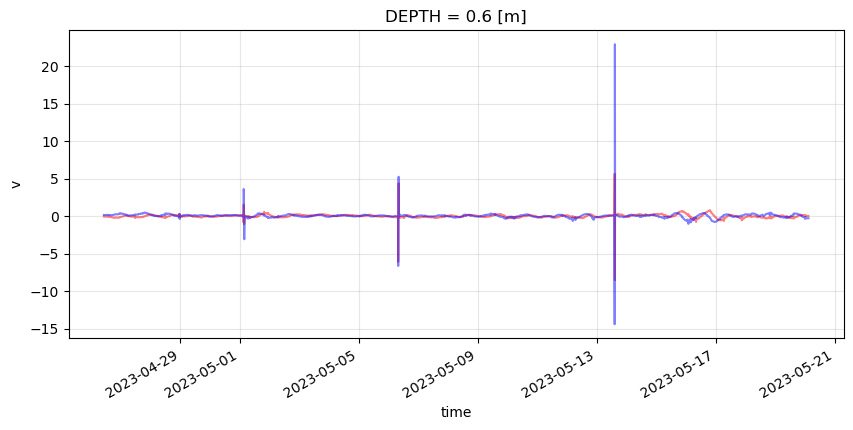

In [21]:
# Check values for spikes
plt.figure(figsize=(10,4))
u.plot(alpha = 0.5, color = "red");
v.plot(alpha = 0.5, color = "blue");
plt.grid(alpha=0.3)

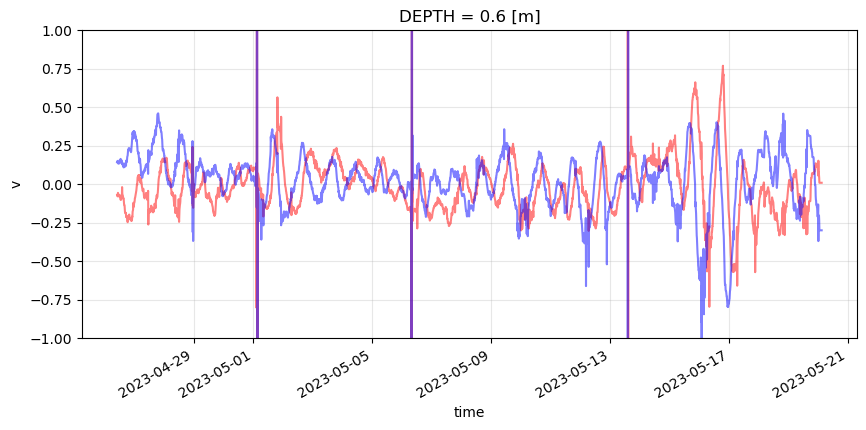

In [22]:
# Limit y axis to see velocity time series
plt.figure(figsize=(10,4))
u.plot(alpha = 0.5, color = "red");
v.plot(alpha = 0.5, color = "blue");
plt.ylim(-1,1)
plt.grid(alpha=0.3)

In [23]:
# Add variables to the dataset
ds02 = ds02.assign(U=u)
ds02 = ds02.assign(V=v)
print(list(ds02.keys()))

['BAT_STATUS', 'LAT', 'LON', 'trajectory', 'U', 'V']


<a id="2.4."></a> 
## 2.4. Spike cleaning (not finished)

We will look velocity's module magnitude to identify spikes due to spurious data

In [24]:
abs_vel = (ds02.U**2 + ds02.V**2)**0.5

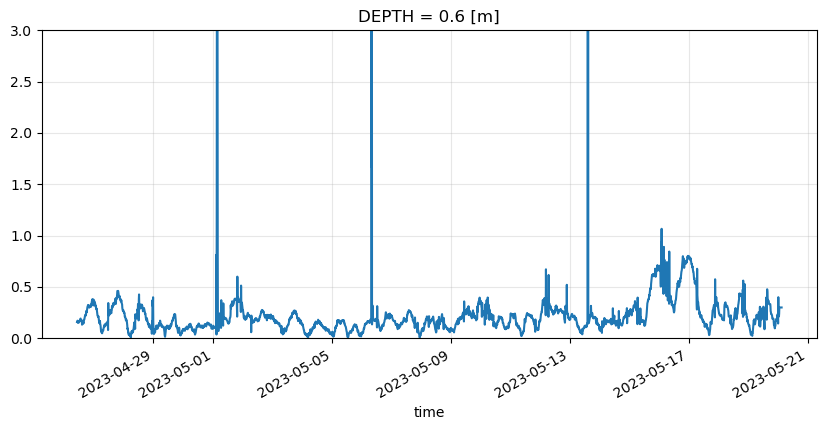

In [25]:
# Overview
plt.figure(figsize=(10,4))
abs_vel.plot()
plt.ylim([0,3])
plt.grid(alpha=0.3)

<a id="2.4.1."></a> 
### 2.4.1. Large spikes removal

We do a first large spike removal by using a large threshold on the absolute velocity / speed.  From looking at vel. plots, 0.8 m/s in this Med. region, is more than enough!)

In [26]:
vel_thres = 0.8 # m/s 
ds03 = ds02.where(abs_vel < vel_thres)

In [27]:
abs_vel = (ds03.U**2 + ds03.V**2)**0.5

<a id="2.4.2."></a> 
### 2.4.2. Smaller spike removal

We will use a moving threshold based on the standard deviation of the window. Values of speed outside this threshold will be marked as spikes

In [28]:
# Number of points of the window
window_data = 12

In [29]:
# Obtain the moving std
speed_std = abs_vel.rolling(time=window_data, center=True).std()
speed_median = abs_vel.rolling(time=window_data, center=True).median()
#speed_std = speed_median.rolling(time=int(window_data/2), center=True).std()

In [30]:
# Overview
import matplotlib.dates as mdates
dates = mdates.date2num(ds02['time'])
dates

array([19473.42361111, 19473.43055556, 19473.4375    , ...,
       19497.11111111, 19497.11805556, 19497.125     ])

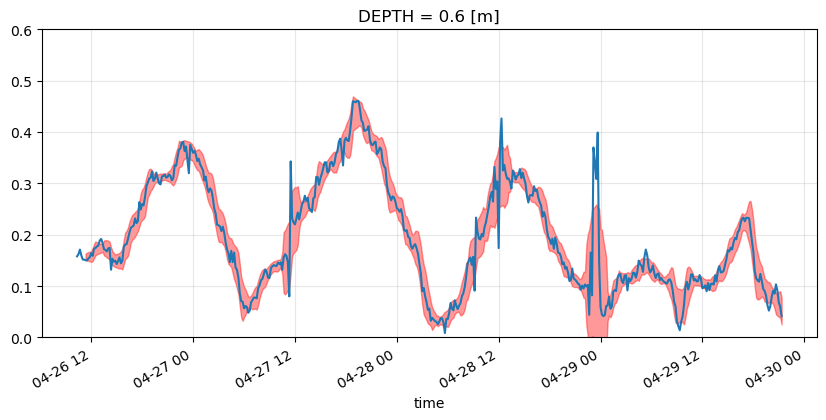

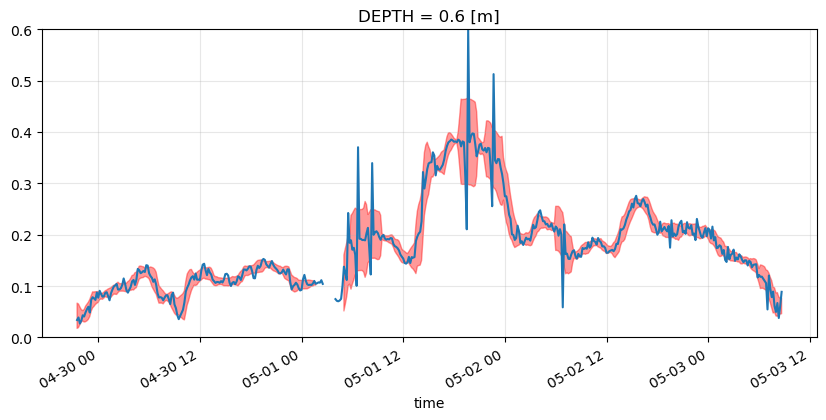

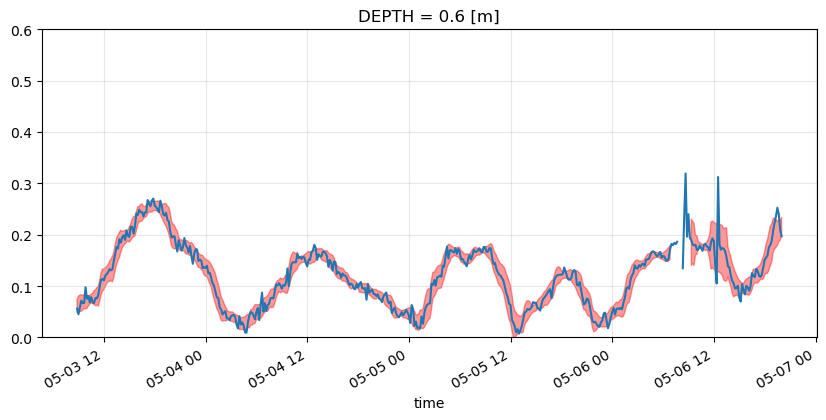

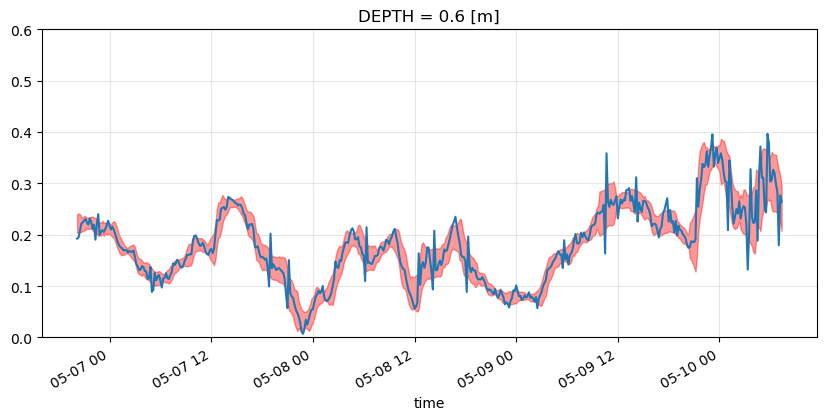

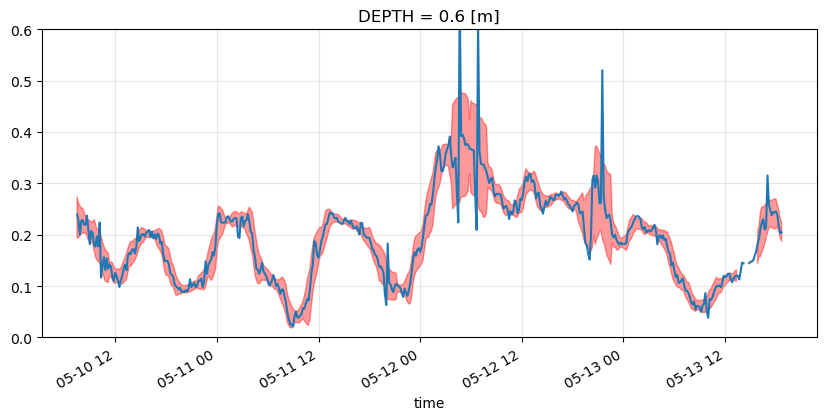

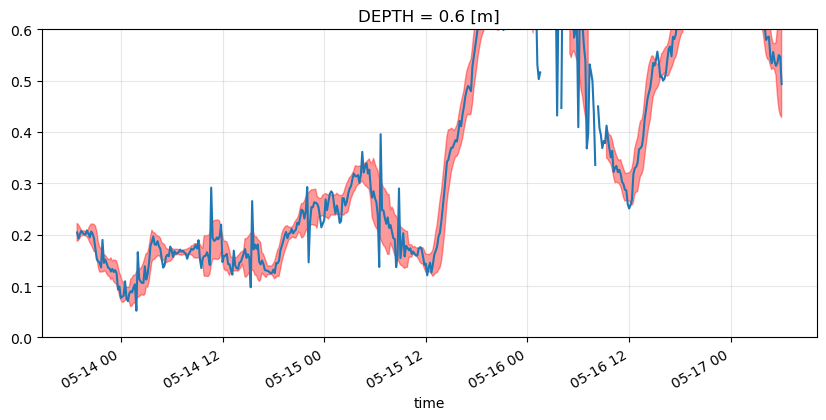

In [31]:
# Zoomed subsamples
tt = 500
for ii in range(0, int(np.floor(len(abs_vel)/tt))):
    plt.figure(figsize=(10,4))
    x = dates[(ii*tt):((ii+1)*tt)]
    y = speed_median[(ii*tt):((ii+1)*tt)]
    std_zoom = speed_std[(ii*tt):((ii+1)*tt)]
    plt.fill_between(x=x, y1=y-std_zoom, y2=y+std_zoom,color='r',alpha=0.4)
    abs_vel[(ii*tt):((ii+1)*tt)].plot()
    plt.ylim([0,0.6])
    plt.grid(alpha=0.3)

In [32]:
# Set limits for spike cleaning
upper_limit = speed_median + speed_std
bottom_limit = speed_median - speed_std

In [33]:
ds04 = ds03.where((abs_vel < upper_limit) & (abs_vel > bottom_limit))

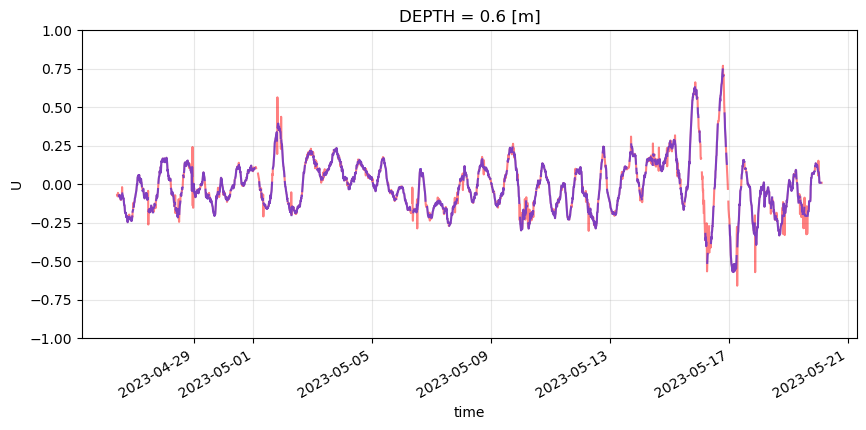

In [34]:
plt.figure(figsize=(10,4))
ds03.U.plot(alpha = 0.5, color = "red");
ds04.U.plot(alpha = 0.5, color = "blue");
plt.ylim(-1,1)
plt.grid(alpha=0.3)

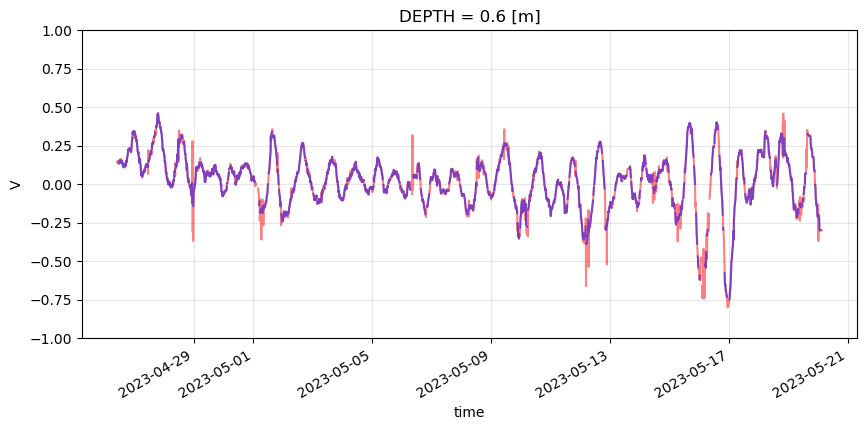

In [35]:
plt.figure(figsize=(10,4))
ds03.V.plot(alpha = 0.5, color = "red");
ds04.V.plot(alpha = 0.5, color = "blue");
plt.ylim(-1,1)
plt.grid(alpha=0.3)

<a id="2.5."></a> 
## 2.5. Smoothing 

<a id="2.5.1."></a> 
### 2.5.1. Interpolation
(again to fill in spike gaps, smoothing method applied (for now) next does not fill in the gaps) --> to check

In [36]:
# To apply interpolate, we need to remove the trajectory variable because it is a string not a float (number)
ds05 = ds04.drop_vars("trajectory") # trajectory variable unnecessary, check with Lara --> not better attrubte?

In [37]:
ds05 = ds05.interpolate_na(dim='time', method="pchip") 
# Pchip : cubic with splines interp. (Dani find ref.)

<a id="2.5.2."></a> 
### 2.5.2. Window smoothing

To remove small scale noise and any remaining spikes.

We apply a window (Hamming, see testing notebooks) to smooth the data on the lon and lat variables of the drifters, to then recalculate vels. 

For now we use n=12 equivalent to a 2h (method to be refined as smoothes too much at peaks, very flat)

In [38]:
ds06 = ds05.copy()

Creating new variables with mirror boundary conditions 

(for testing on this see : http://localhost:8889/notebooks/code/drifters/processing/fast_swot_drifter_processing_rough02.ipynb)

In [39]:
nn = 100 #nb of points at start and end to use for mirroring at borders
lonb = ds05.LON.values
lona = np.flipud(ds05.LON.values[0:nn])
lonc = np.flipud(ds05.LON.values[-nn::])

latb = ds05.LAT.values
lata = np.flipud(ds05.LAT.values[0:nn])
latc = np.flipud(ds05.LAT.values[-nn::])

In [40]:
lon_cat = np.concatenate((lona, lonb, lonc))
lat_cat = np.concatenate((lata, latb, latc))

Applying the window smoothing

In [41]:
window = signal.windows.hamming(12) # 2 hours (12 points) 


In [42]:
lon_win = signal.convolve(lon_cat, window, mode='same') / np.sum(window)
ds06["LON"][:] = lon_win[nn:-nn]

lat_win = signal.convolve(lat_cat, window, mode='same') / np.sum(window)
ds06["LAT"][:] = lat_win[nn:-nn]

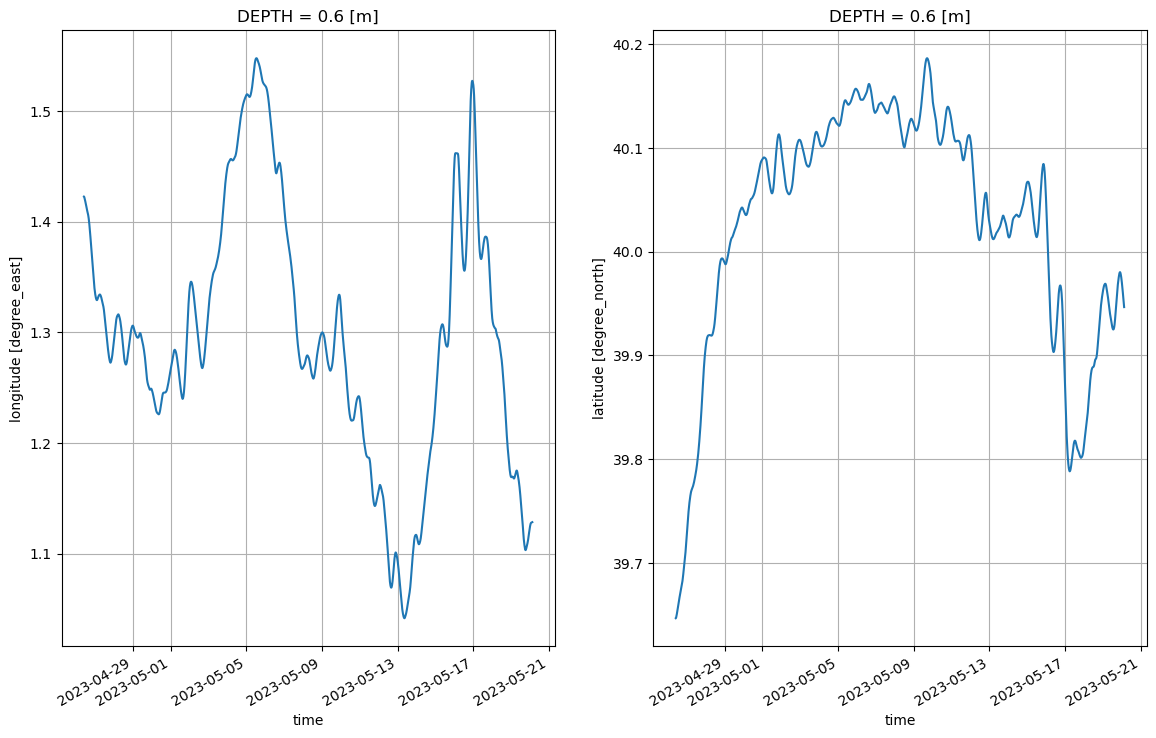

In [58]:
plt.figure(figsize=(14,8))
plt.subplot(121)
ds06.LON.plot.line('-')
plt.grid()
plt.subplot(122)
ds06.LAT.plot()
plt.grid()

<a id="2.6."></a> 
## 2.6. Recalculate Velocity 

In [43]:
# Calculate forward and backward finite differences
_, ufor, vfor = latlon2uv_dir(ds06.LAT, ds06.LON, 10*60, 'forward')
_, uback, vback = latlon2uv_dir(ds06.LAT, ds06.LON, 10*60, 'back')

In [44]:
# Calculate central value
u = (ufor + uback) / 2
v = (vfor + vback) / 2

In [45]:
ds = ds06.copy()

In [46]:
# Add variables to the dataset
ds = ds.assign(U=u)
ds = ds.assign(V=v)
list(ds.keys())

['BAT_STATUS', 'LAT', 'LON', 'U', 'V']

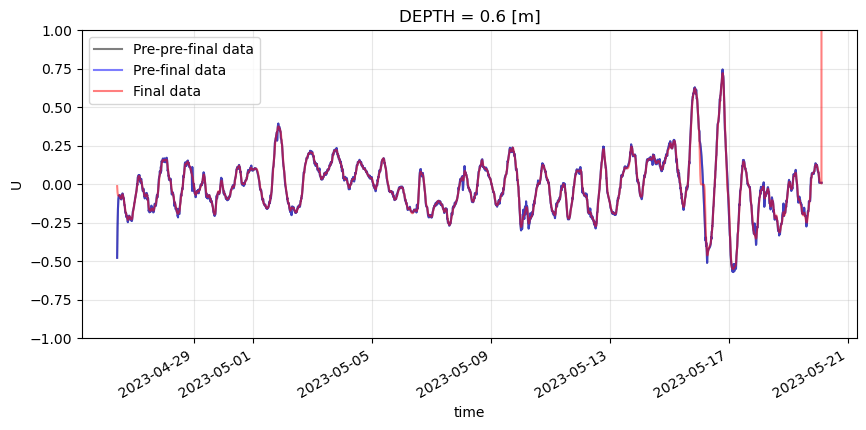

In [47]:
# Limit y axis to see velocity time series
plt.figure(figsize=(10,4))
ds05.U.plot(alpha = 0.5, color = "k", label='Pre-pre-final data');
ds06.U.plot(alpha = 0.5, color = "b", label='Pre-final data');
ds.U.plot(alpha = 0.5, color = "r", label='Final data');
plt.ylim(-1,1)
plt.grid(alpha=0.3)
plt.legend()